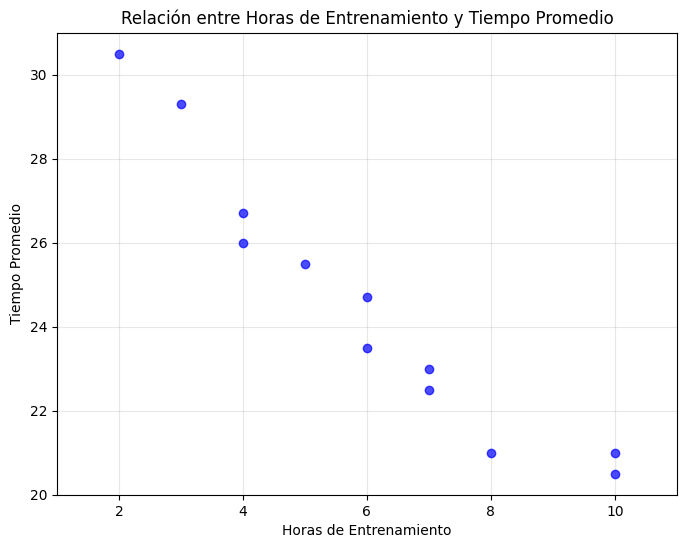

Coeficiente de correlación (Pearson): -0.960


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter

horas_entrenamiento = [2, 3, 4, 4, 5, 6, 6, 7, 7, 8, 10, 10]

tiempo_promedio = [30.5, 29.3, 26.7, 26, 25.5, 24.7, 23.5, 23, 22.5, 21, 21, 20.5]

X = np.array(horas_entrenamiento)
Y = np.array(tiempo_promedio)

# Gráfica de dispersión
plt.figure(figsize=(8, 6))
plt.plot(X, Y, 'o', color='blue', alpha=0.7, markersize=6)
plt.title('Relación entre Horas de Entrenamiento y Tiempo Promedio')
plt.xlabel('Horas de Entrenamiento')
plt.ylabel('Tiempo Promedio')
plt.grid(True, alpha=0.3)
plt.xlim(1, 11)
plt.ylim(20, 31)
plt.show()

# Cálculo del coeficiente de correlación
correlacion = np.corrcoef(X, Y)[0, 1]
print(f"Coeficiente de correlación (Pearson): {correlacion:.3f}")

In [2]:
import sys
import os

# Ruta absoluta a la carpeta "Fuentes"
ruta_fuentes = os.path.abspath(os.path.join(os.getcwd(), "..", "Fuentes"))
sys.path.append(ruta_fuentes)

from ClassNeuronaLineal import NeuronaLineal

x_train = X.reshape(-1,1)    # selecciona entradas y formatea a Nx1
y_train = Y.reshape(-1,1)    # selecciona salidas y formatea a Nx1

# entrena neurona lineal y grafica
modelo = NeuronaLineal(alpha=0.01, n_iter=500, cotaE=0.1, draw=0, title=['Horas', 'Tiempo'])
modelo = modelo.fit(x_train, y_train)
print('w =', modelo.w_[0])
print('b =', modelo.b_[0])

dato = 9 # horas de estudio dedicadas
print('Quien dedicó %d horas de entrenamiento tardará %d como tiempo promedio' % (dato, modelo.predict([dato])[0]))   # prediccio

w = -0.951927776743861
b = 30.014088025227814
Quien dedicó 9 horas de entrenamiento tardará 21 como tiempo promedio


In [3]:
learning = 0.0005
epochs = 5000
# b0 es la ordenada al origen y b1 la pendiente de la recta de regresion lineal simple
b0, b1 = 0.0, 0.0

rng = np.random.default_rng(42)

for epoch in range(epochs):
    # ACÁ SE DA LO DE LOS MINILOTES, TOMAMOS UNA PERMUTACION RANDOM DE LAS VARAIABLES PARA CALCULAR ERROR
    indicies = rng.permutation(len(X))
    for i in indicies:
        xi = X[i]
        yi = Y[i]
        # Predicción de una variable actual
        y_pred = b0 + b1 * xi
        error = y_pred - yi
        # Actualizacion de ordenada al origen y pendiente
        b0 -= learning * error
        b1 -= learning * error * xi

print ("El b0 es", b0, "y el b1 es", b1)

# Punto de e)
X = 9
predict = b0 + b1 * X
print("Predicción para 9 horas de entrenamiento sin estandarizar:", predict)

El b0 es 31.324525786512535 y el b1 es -1.1442871804743586
Predicción para 9 horas de entrenamiento sin estandarizar: 21.025941162243306


In [7]:
import pandas as pd

ds_path = "../Datos/FrutasTrain.csv"

try:
    df = pd.read_csv(ds_path)
    pd.set_option('display.float_format', '{:.4f}'.format)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"\n🔍 Primeras 5 filas:")
    display(df.head(5))
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado exitosamente!

🔍 Primeras 5 filas:


,Diametro,Color,Clase
0,10,200,Naranja
1,20,30,Melon
2,8,150,Naranja
3,26,30,Melon
4,7,170,Naranja


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from ClassNeuronaGral import NeuronaGradiente

X = df[["Diametro", "Color"]].values
T = np.where(df["Clase"] == "Naranja", 1, -1)

scaler = StandardScaler()

X = scaler.fit_transform(X)
X = scaler.transform([14, 140])

print(X)

modelo = NeuronaGradiente(alpha=0.01, n_iter=50, cotaE=10E-07, FUN='tanh')
modelo.w_ = [2.65, -2.5]
modelo.b_ = 0.03

Y = modelo.predict_nOut(X)



mse = np.mean((T - Y)**2)

print(Y)

ValueError: Expected 2D array, got 1D array instead:
array=[ 14. 140.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.